# Duffing Oscillator Benchmark

Discrete-time Duffing oscillator benchmark for regional-ISS certificate.

**Model (continuous-time):**
$$\ddot{q} = -\delta_d\,\dot{q} - q + q^3 + u(t), \quad \delta_d > 0$$

States $x = (q,\dot{q})^\top$.

**Fixed points (u=0):**
- $(0, 0)$: **stable** (spiral sink)
- $(\pm 1, 0)$: **saddle** — form the basin boundary (separatrix)

Trajectories inside the separatrix converge to the origin.  
Trajectories outside diverge to $\pm\infty$.  
Input $u$ can push a trajectory over the saddle, triggering true divergence.

Target equilibrium: $(0, 0)$. Discretised with RK4 at $T_s = 0.05$ s.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from scipy.integrate import quad_vec
import os

# ── figure output directory ────────────────────────────────────────────────
FIG_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'figs')
os.makedirs(FIG_DIR, exist_ok=True)

# ── system parameters ──────────────────────────────────────────────────────
DELTA_D = 0.3   # damping coefficient
TS      = 0.05  # sample time [s]

# Energy function: V(q, dq) = dq^2/2 - q^2/2 + q^4/4
# Saddle energy: V(1, 0) = -1/4  =>  separatrix is the level set V = -0.25
V_SADDLE = -0.25

def V_energy(q, dq):
    return dq**2/2 - q**2/2 + q**4/4

print(f'delta_d = {DELTA_D},  Ts = {TS} s')
print(f'Saddle energy V(1,0) = {V_SADDLE}')

delta_d = 0.3,  Ts = 0.05 s
Saddle energy V(1,0) = -0.25


## 1  System definition

In [2]:
def duffing_ct(t, x, u=0.0, delta_d=DELTA_D):
    """Continuous-time Duffing RHS: q'' = -delta_d*q' - q + q^3 + u."""
    q, dq = x
    ddq = -delta_d * dq - q + q**3 + u
    return [dq, ddq]


def duffing_dt(x, u=0.0, Ts=TS, delta_d=DELTA_D):
    """One RK4 step of the Duffing system (ZOH input)."""
    f  = lambda t, xv: duffing_ct(t, xv, u=u, delta_d=delta_d)
    sol = solve_ivp(f, [0, Ts], x, method='RK45',
                    rtol=1e-5, atol=1e-7, dense_output=False)
    return sol.y[:, -1]


def simulate(x0, u_seq, Ts=TS, delta_d=DELTA_D, diverge_thresh=50.0):
    """Simulate the discrete-time Duffing system.
    Returns state trajectory X (T+1, 2), output y = q, and diverged flag.
    Stops early if |state| > diverge_thresh.
    """
    T = len(u_seq)
    X = [np.array(x0, dtype=float)]
    diverged = False
    for k in range(T):
        xnew = duffing_dt(X[-1], u=u_seq[k], Ts=Ts, delta_d=delta_d)
        X.append(xnew)
        if np.any(np.abs(xnew) > diverge_thresh):
            diverged = True
            break
    X = np.array(X)
    y = X[:, 0]
    return X, y[:-1], diverged


# ── Section 3b: RK45 vs. forward-Euler discretisation comparison ────────
# duffing_dt() uses one RK45 step (accurate).  Here we compare against
# a plain forward-Euler step:  x^{k+1} = x^k + Ts * f(x^k, u^k)
# using the FULL nonlinear Duffing RHS (not the linearised A_d, B_d).

def duffing_euler(x, u=0.0, Ts=TS, delta_d=DELTA_D):
    """One forward-Euler step of the Duffing system."""
    q, dq = x
    ddq = -delta_d * dq - q + q**3 + u
    return np.array([q + Ts * dq, dq + Ts * ddq])


def simulate_euler(x0, u_seq, Ts=TS, delta_d=DELTA_D, diverge_thresh=50.0):
    """Simulate with forward-Euler steps."""
    T = len(u_seq)
    X = [np.array(x0, dtype=float)]
    diverged = False
    for k in range(T):
        xnew = duffing_euler(X[-1], u=u_seq[k], Ts=Ts, delta_d=delta_d)
        X.append(xnew)
        if np.any(np.abs(xnew) > diverge_thresh):
            diverged = True
            break
    X = np.array(X)
    y = X[:, 0]
    return X, y, diverged


# ── verify fixed-point structure ───────────────────────────────────────────
print('Fixed points (eigenvalues of Jacobian):')
for q_star in [0.0, 1.0, -1.0]:
    J = np.array([[0, 1], [-1 + 3*q_star**2, -DELTA_D]])
    eigs = np.linalg.eigvals(J)
    kind = 'stable' if all(e.real < 0 for e in eigs) else 'SADDLE'
    print(f'  q* = {q_star:+.0f}:  eigs = {eigs.round(3)}  ({kind})')

print()
# quick sanity check: x0 inside basin (should converge)
T_test = 400
X0, y0, div = simulate([0.7, 0.0], np.zeros(T_test))
print(f'x0=(0.7,0), u=0: diverged={div}, final={X0[-1].round(4)}  (should -> (0,0))')

# x0 outside basin (should diverge)
X1, y1, div1 = simulate([1.05, 0.0], np.zeros(T_test))
print(f'x0=(1.05,0), u=0: diverged={div1}  (should diverge)')

Fixed points (eigenvalues of Jacobian):
  q* = +0:  eigs = [-0.15+0.989j -0.15-0.989j]  (stable)
  q* = +1:  eigs = [ 1.272 -1.572]  (SADDLE)
  q* = -1:  eigs = [ 1.272 -1.572]  (SADDLE)

x0=(0.7,0), u=0: diverged=False, final=[ 0.0328 -0.005 ]  (should -> (0,0))
x0=(1.05,0), u=0: diverged=True  (should diverge)


In [3]:
# euler linearization
J_c = np.array([[0.0, 1.0], [-1.0, -DELTA_D]])

A_d2 = np.eye(2) + J_c * TS
B_d2 = np.array([[0.0], [TS]])

In [4]:
def dzn(z):
    """Scalar deadzone: max(|z| - 1, 0) * sign(z)."""
    return np.maximum(np.abs(z) - 1, 0.0) * np.sign(z)

In [5]:
nz = 20
DZN_RANGE   = 5     # fit on [-DZN_RANGE, DZN_RANGE]
d_thresh    = np.linspace(0.0, DZN_RANGE, nz + 1)[1:]  # avoid d=0

z_fit  = np.linspace(-DZN_RANGE, DZN_RANGE, 500)
Phi_fit = np.column_stack([d*dzn(z_fit/d) for d in d_thresh])   # (600, K)
W, *_ = np.linalg.lstsq(Phi_fit, z_fit**3, rcond=None)

In [6]:
W.shape

(20,)

In [7]:
d_thresh

array([0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75,
       3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  ])

In [8]:

A = A_d2
B = B_d2
C = np.array([[1.0, 0.0]])
D = np.zeros((1, 1))
B2 = TS*np.vstack((
    np.zeros((1,nz)),
    W.reshape(1,-1) @ np.diag(d_thresh)
    ))
C2 = np.hstack((
    1/d_thresh.reshape(-1,1), np.zeros((nz, 1))
))
D12 = np.zeros((1, nz))
D21 = np.zeros((nz, 1))

B2_1 = np.vstack((
    np.zeros((1,nz)),
    W.reshape(1,-1) @ np.diag(d_thresh)
    ))

# ── 7.6  Save Lur'e model parameters for use in duffing_analysis.ipynb ────────
lure_params_path = os.path.join('datasets', 'Duffing', 'lure_model_params.npz')
np.savez(lure_params_path,
         A=A, B=B, B2=B2, C=C, C2=C2,
         D=D, D12=D12, D21=D21,
         TS=TS, nz=nz, nx=A.shape[0], nu=B.shape[1], ny=C.shape[0])
print(f'Saved Lur\'e model parameters to {lure_params_path}')

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/Duffing/lure_model_params.npz'

In [9]:
print(f'B2:{B2}, C2:{C2}, B: {B}, C:{C}')

B2:[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.00556457 0.01755953 0.04252413 0.07508705 0.11689463 0.16913675
  0.22928246 0.30034822 0.37948621 0.46870539 0.56760693 0.67407641
  0.79379072 0.91629349 1.05828194 1.19480956 1.36282576 1.50314181
  1.73255    0.        ]], C2:[[4.         0.        ]
 [2.         0.        ]
 [1.33333333 0.        ]
 [1.         0.        ]
 [0.8        0.        ]
 [0.66666667 0.        ]
 [0.57142857 0.        ]
 [0.5        0.        ]
 [0.44444444 0.        ]
 [0.4        0.        ]
 [0.36363636 0.        ]
 [0.33333333 0.        ]
 [0.30769231 0.        ]
 [0.28571429 0.        ]
 [0.26666667 0.        ]
 [0.25       0.        ]
 [0.23529412 0.        ]
 [0.22222222 0.        ]
 [0.21052632 0.        ]
 [0.2        0.        ]], B: [[0.  ]
 [0.05]], C:[[1. 0.]]


In [10]:
def man_nonlinearity(x, u):
    x_v = np.array([[x] , [0.0]])
    u_v = u.reshape((1, 1))
    z = C2 @ x_v + D21 @ u_v
    w = dzn(z)
    return (B2 @ w)[1]

In [11]:
N = 100
xs = np.linspace(-2.0, 2.0, N)
us = np.zeros((N, 1))

y_hats = []
for xi, ui in zip(xs, us):
    y_hats.append(man_nonlinearity(xi,ui)) 

Text(0, 0.5, '$y$')

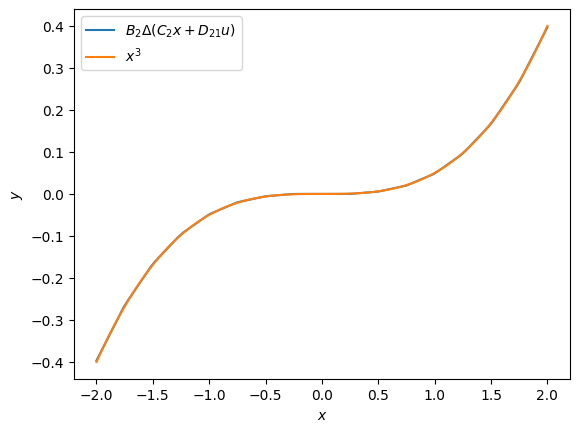

In [12]:
fig, ax = plt.subplots()
ax.plot(xs, np.array(y_hats), label=r'$B_2 \Delta(C_2 x + D_{21} u)$')
ax.plot(xs, TS*xs**3, label=r'$x^3$')
ax.legend()
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

In [13]:
class LureModel:
    def __init__(self, A, B, B2, C, C2, D, D12, D21, psi=dzn):
        self.A = A
        self.B = B
        self.B2 = B2
        self.C = C
        self.C2 = C2
        self.D = D
        self.D12 = D12
        self.D21 = D21
        self.psi = psi
    def step(self, x, u):
        u = np.asarray(u).reshape(-1)
        z = self.C2 @ x + self.D21 @ u
        w = self.psi(z)
        y_hat = self.C @ x + self.D @ u + self.D12 @ w
        x = self.A @ x + self.B @ u + self.B2 @ w
        return y_hat, x
    def simulate(self, x0, u_seq, psi=dzn, diverge_thresh=50.0):
        X = [x0.copy()]
        Y = []
        diverged = False
        for u in u_seq:
            y_hat, x = self.step(X[-1], u)
            if np.any(np.abs(x)>diverge_thresh):
                diverged = True
                break
            X.append(x)
            Y.append(y_hat)
        return np.array(X), np.array(Y).reshape(-1), diverged

Inside basin  $x_0=(0.5, 0)$:  max|Δq|=0.0360,  max|Δq̇|=0.0337
Near saddle   $x_0=(0.85, 0)$:  max|Δq|=0.0487,  max|Δq̇|=0.0450


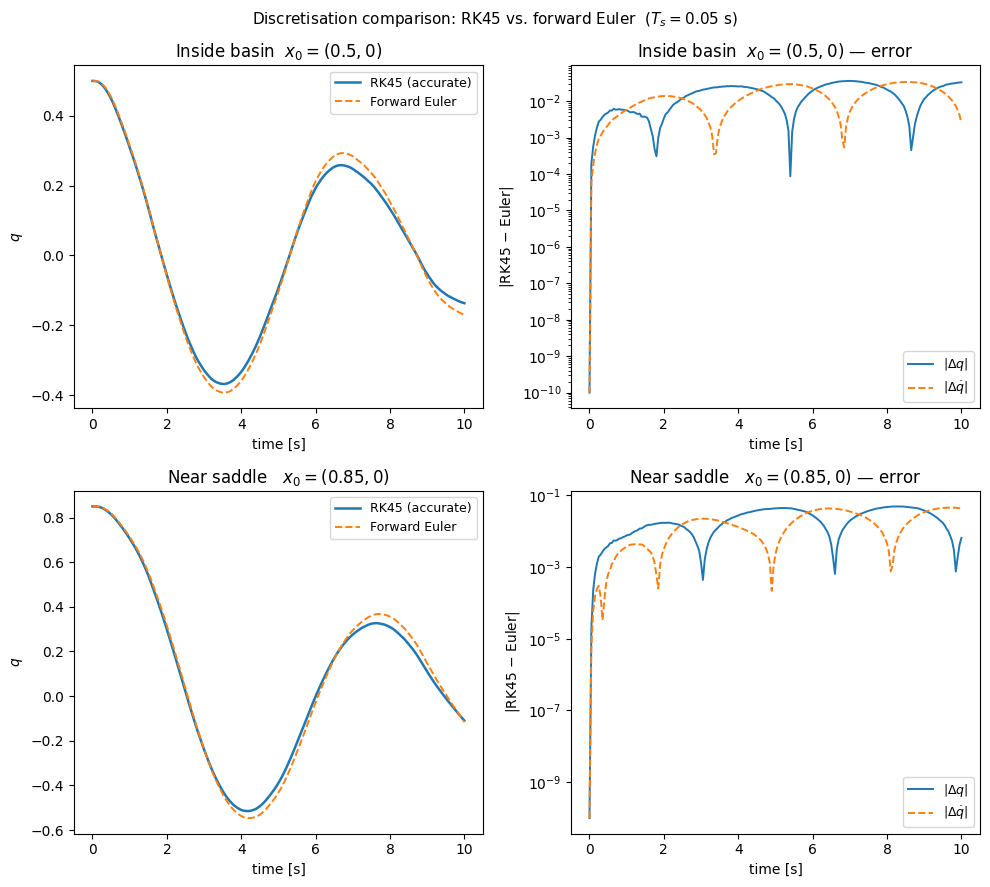

Saved: figs/duffing_euler_vs_rk45.pdf


In [15]:


# Compare on a converging and a near-separatrix trajectory
rng_cmp = np.random.default_rng(17)
T_cmp   = 200
u_cmp   = np.clip(rng_cmp.normal(0.0, 0.2, T_cmp), -0.35, 0.35)
t_cmp   = np.arange(T_cmp + 1) * TS

cases = [
    ('Inside basin  $x_0=(0.5, 0)$',      np.array([0.5, 0.0])),
    ('Near saddle   $x_0=(0.85, 0)$',     np.array([0.85, 0.0])),
]

fig, axes = plt.subplots(len(cases), 2, figsize=(10, 4.5 * len(cases)), squeeze=False)

for row, (title, x0_c) in enumerate(cases):
    X_rk, _, _ = simulate(x0_c, u_cmp)
    X_eu, _, _    = simulate_euler(x0_c, u_cmp)

    T_plot = min(len(X_rk), len(X_eu)) - 1
    t_p    = t_cmp[:T_plot + 1]

    # time series
    ax = axes[row, 0]
    ax.plot(t_p, X_rk[:T_plot+1, 0],  'C0-',  lw=1.8, label='RK45 (accurate)')
    ax.plot(t_p, X_eu[:T_plot+1, 0],  'C1--', lw=1.4, label='Forward Euler')
    ax.set_title(title)
    ax.set_ylabel('$q$')
    ax.set_xlabel('time [s]')
    ax.legend(fontsize=9)

    # absolute error
    err_q  = np.abs(X_rk[:T_plot+1, 0] - X_eu[:T_plot+1, 0])
    err_dq = np.abs(X_rk[:T_plot+1, 1] - X_eu[:T_plot+1, 1])
    ax2 = axes[row, 1]
    ax2.semilogy(t_p, err_q  + 1e-10, 'C0-',  lw=1.4, label='$|\\Delta q|$')
    ax2.semilogy(t_p, err_dq + 1e-10, 'C1--', lw=1.4, label='$|\\Delta\\dot{q}|$')
    ax2.set_title(title + ' — error')
    ax2.set_ylabel('|RK45 $-$ Euler|')
    ax2.set_xlabel('time [s]')
    ax2.legend(fontsize=9)

    max_eq  = np.max(err_q)
    max_edq = np.max(err_dq)
    print(f'{title}:  max|Δq|={max_eq:.4f},  max|Δq̇|={max_edq:.4f}')

plt.suptitle(
    f'Discretisation comparison: RK45 vs. forward Euler  ($T_s = {TS}$ s)',
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'duffing_euler_vs_rk45.pdf'), bbox_inches='tight')
plt.show()
print('Saved: figs/duffing_euler_vs_rk45.pdf')


## 4  Dataset generation

Four trajectory groups are generated and saved individually to
`datasets/Duffing/raw/` with filenames that encode the case:

| Group | Filename prefix | Start | Outcome |
|-------|----------------|-------|---------|
| `zero_conv` | `zero_conv_NNN.csv` | $x_0 = 0$ | converging |
| `zero_div`  | `zero_div_NNN.csv`  | $x_0 = 0$ | diverging  |
| `rand_conv` | `rand_conv_NNN.csv` | $x_0 \sim U$ | converging |
| `rand_div`  | `rand_div_NNN.csv`  | $x_0 \sim U$ | diverging  |

All four groups enter the training pipeline after the 60/10/30 split.
One representative trajectory per group is plotted for visual inspection.

**Input design:** low-pass filtered white noise (Butterworth, order 4,
cutoff $f_c = 0.3\,\text{Hz} \approx 2\,f_n$) peak-normalised to
$[-U_{\max}, U_{\max}]$.  This gives smooth, band-limited excitation
concentrated around the system's natural frequency
($f_n = 1/(2\pi) \approx 0.16\,\text{Hz}$) without artificial
periodicity.


In [16]:
model = LureModel(A, B, B2, C, C2, D, D12, D21)

In [29]:
import csv, os, shutil

rng = np.random.default_rng(42)

N_ZERO_CONV =  0   # converging from x0 = 0
N_ZERO_DIV  =  0   # diverging  from x0 = 0
N_RAND_CONV =  50   # converging from random x0
N_RAND_DIV  =  0   # diverging  from random x0
T_TRAJ      = 4000
U_AMP_MAX   = 2
LP_CUTOFF   = 2.0   # Hz  LP filter cutoff (~12x natural freq 0.16 Hz; covers resonance + cubic harmonics)
LP_ORDER    =   4   # Butterworth filter order
ENV_DECAY   = 0.9  # mild exponential envelope strength over one trajectory

RAW_DIR = os.path.join('datasets', 'Duffing', 'raw')
if os.path.exists(RAW_DIR):
    shutil.rmtree(RAW_DIR)
os.makedirs(RAW_DIR)

GROUPS = [
    ('zero_conv', N_ZERO_CONV, False, lambda: np.array([0.0, 0.0])),
    ('zero_div',  N_ZERO_DIV,  True,  lambda: np.array([0.0, 0.0])),
    ('rand_conv', N_RAND_CONV, False,
     lambda: rng.uniform(-0.6, 0.6, 2)),
    ('rand_div',  N_RAND_DIV,  True,
     lambda: rng.uniform(-0.6, 0.6, 2)),
]



In [32]:
def make_u(rng, T, amp_max, f_cut=LP_CUTOFF, order=LP_ORDER, env_decay=ENV_DECAY):
    """Low-pass filtered white noise with optional exponential decay envelope.

    White noise is generated at the sample rate 1/TS and filtered with a
    Butterworth LP filter of the given cutoff frequency (Hz) and order.
    The resulting signal is multiplied by exp(-env_decay * t_norm), where
    t_norm spans [0, 1], then peak-normalised to a random fraction of amp_max.
    """
    from scipy.signal import butter, filtfilt
    # design filter (normalised cutoff = f_cut / Nyquist)
    b, a = butter(order, f_cut / (0.5 / TS), btype='low')
    # generate and filter; use extra samples to avoid edge transients
    pad   = 4 * order
    noise = rng.standard_normal(T + pad)
    u_filt = filtfilt(b, a, noise)[pad:]
    # apply mild exponential decay envelope across trajectory length
    t_norm = np.linspace(0.0, 1.0, T)
    envelope = np.exp(-env_decay * t_norm)
    u_filt = u_filt * envelope
    # peak-normalise to a random fraction of amp_max
    peak = np.max(np.abs(u_filt))
    if peak > 0:
        u_filt = u_filt / peak * rng.uniform(0.0, amp_max)
    return u_filt

def write_traj_csv(path, u_seq, X):
    """Write u, q, q_dot columns for the real simulated steps only."""
    n_real = min(len(u_seq), len(X) - 1)
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['u', 'q', 'q_dot'])
        for k in range(n_real):
            w.writerow([round(float(u_seq[k]), 8),
                        round(float(X[k, 0]),  8),
                        round(float(X[k, 1]),  8)])



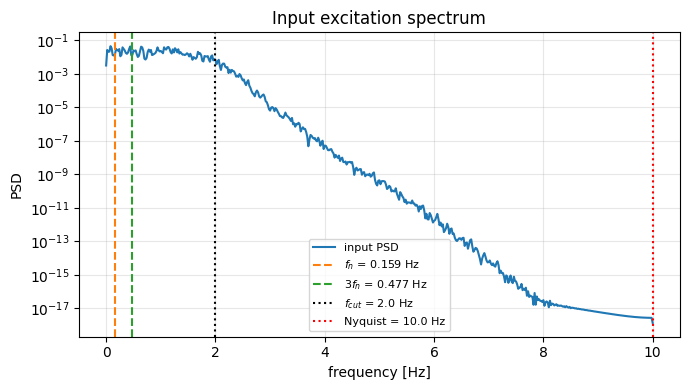

In [33]:
# ── Diagnostic: power spectral density of make_u output ──────────────────
# Verifies which frequencies are actually excited by the input signal.
# Reference lines: f_n (linear natural freq), 3*f_n (first cubic harmonic),
# LP_CUTOFF (filter knee), Nyquist (highest representable freq at sample rate).
from scipy.signal import welch

rng_dbg = np.random.default_rng(0)
u_dbg = make_u(rng_dbg, T_TRAJ, U_AMP_MAX)
f_psd, Pxx = welch(u_dbg, fs=1/TS, nperseg=min(2048, len(u_dbg)//4))

omega_n = 1.0                     # rad/s, linearised natural frequency
f_n     = omega_n / (2*np.pi)     # ~0.159 Hz

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(f_psd, Pxx, label='input PSD')
ax.axvline(f_n,       color='C1', ls='--', label=f'$f_n$ = {f_n:.3f} Hz')
ax.axvline(3*f_n,     color='C2', ls='--', label=f'$3 f_n$ = {3*f_n:.3f} Hz')
ax.axvline(LP_CUTOFF, color='k',  ls=':',  label=f'$f_{{cut}}$ = {LP_CUTOFF} Hz')
ax.axvline(0.5/TS,    color='r',  ls=':',  label=f'Nyquist = {0.5/TS} Hz')
ax.set_xlabel('frequency [Hz]')
ax.set_ylabel('PSD')
ax.set_title('Input excitation spectrum')
ax.legend(fontsize=8); ax.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()


zero_conv   :   0 saved  (0 attempts)
zero_div    :   0 saved  (0 attempts)
rand_conv   :  50 saved  (78 attempts)
rand_div    :   0 saved  (0 attempts)

Raw CSVs in datasets/Duffing/raw/  (50 files)


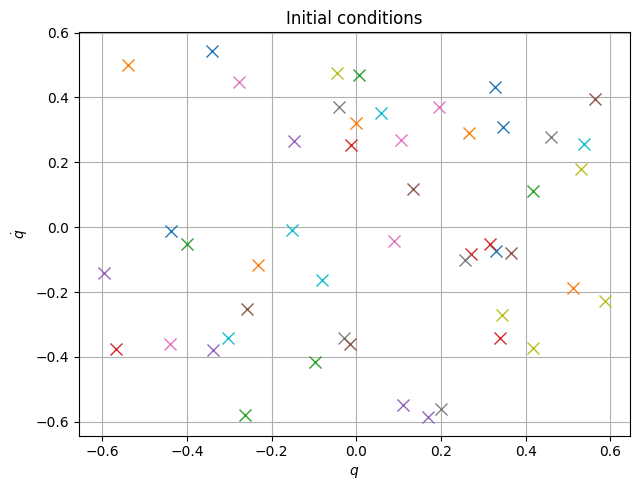

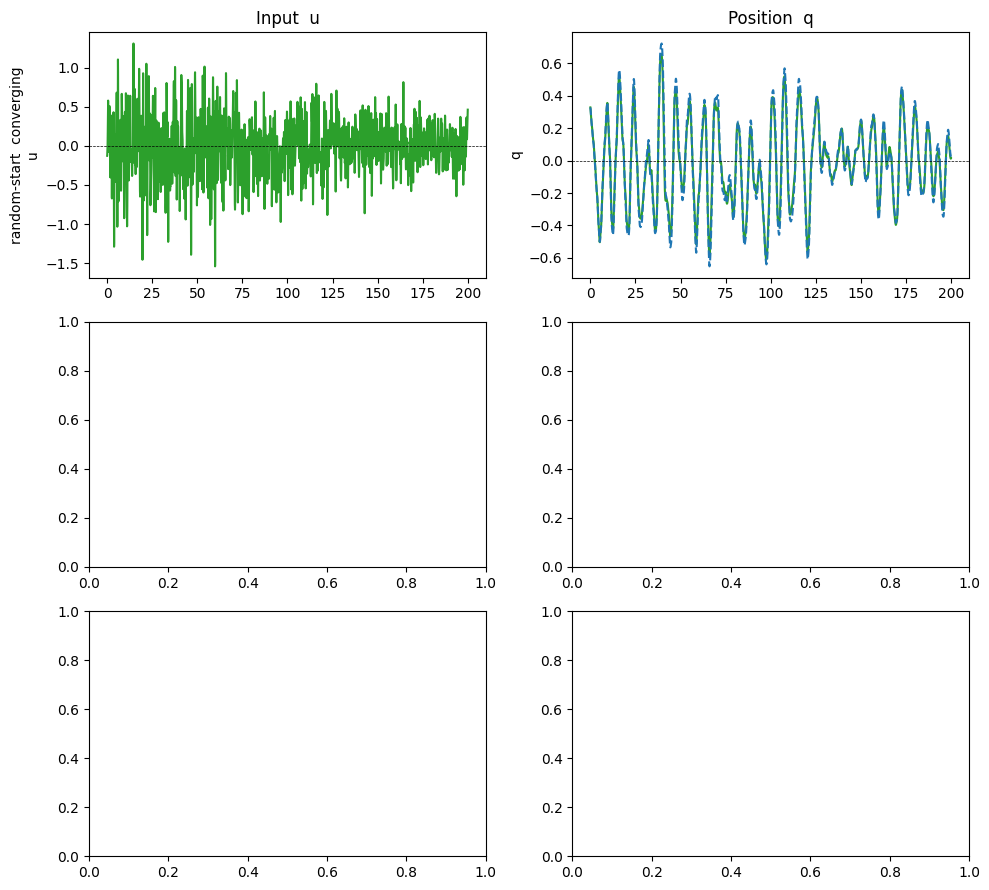

In [34]:


# print(fr's^2 (1-\alpha^(2T))= {s**2*(1-alpha**(2*T_TRAJ)):.6f}  T={T_TRAJ} steps')
# print(fr's^2 =  {s**2:.6f}')
# print(fr's^2 (1-\alpha^2) = {s**2*(1-alpha**2):.6f}')

fig2, ax2 = plt.subplots(figsize=(6.5, 5))
ax2.set_title('Initial conditions', fontsize=12)

all_groups = {}
for gname, n_target, want_div, x0_fn in GROUPS:
    trajs    = []
    attempts = 0
    while len(trajs) < n_target:
        x0    = x0_fn()
        u_seq = make_u(rng, T_TRAJ, U_AMP_MAX)
        X, y, div = simulate(x0, u_seq,diverge_thresh=2.0)
        X2, y2, _ = model.simulate(x0, u_seq)
        # try:
        #     # print(f'|y-y_lure|={np.sum(np.abs(y-y2))}')
        # except:
        #     print(div)
        attempts += 1
        if div != want_div:
            continue
        idx  = len(trajs)
        path = os.path.join(RAW_DIR, f'{gname}_{idx:03d}.csv')
        write_traj_csv(path, u_seq, X)
        ax2.plot(x0[0], x0[1], 'x', markersize=8)
        # print(f'{gname}: sum of squared inputs = {np.sum(u_seq**2):.6f}')
        # print(f'{gname}: max input = {np.max(np.abs(u_seq)):.6f}')
        trajs.append({'x0': x0, 'u': u_seq, 'X': X, 'X2':X2,
                      'kind': gname, 'path': path})
    all_groups[gname] = trajs
    print(f'{gname:12s}: {len(trajs):3d} saved  ({attempts} attempts)')

ax2.grid()
ax2.set_xlabel('$q$')
ax2.set_ylabel('$\\dot{q}$')
plt.tight_layout()

print(f'\nRaw CSVs in {RAW_DIR}/  ({len(os.listdir(RAW_DIR))} files)')

# ── visual inspection: one example per group ─────────────────────────────
t_axis = np.arange(T_TRAJ) * TS



# fig, axes = plt.subplots(4, 2, figsize=(10, 9))
fig, axes = plt.subplots(3, 2, figsize=(10, 9))
# fig.suptitle('One representative trajectory per group', fontsize=12)
COLORS = {'zero_conv': 'tab:blue', 'zero_div': 'tab:red',
          'rand_conv': 'tab:green', 'rand_div': 'tab:orange'}
LABELS = {'zero_conv': 'zero-start  converging',
          'zero_div':  'zero-start  diverging',
          'rand_conv': 'random-start  converging',
          'rand_div':  'random-start  diverging'}

# for row, gname in enumerate(['zero_conv', 'rand_conv', 'rand_div']):
for row, gname in enumerate(['rand_conv']):
# for row, gname in enumerate(['zero_conv', 'rand_conv']):
# for row, gname in enumerate(['zero_conv', 'zero_div']):
    traj  = all_groups[gname][0]     # first trajectory in each group
    u_seq = np.array(traj['u'])
    X_arr = traj['X']
    
    X_arr2 = traj['X2']
    n_pts = min(len(u_seq), len(X_arr) - 1)
    n_pts2 = min(len(u_seq), len(X_arr2)-1)
    t_plt = t_axis[:n_pts]
    t_plt2 = t_axis[:n_pts2]
    color = COLORS[gname]

    ax_u, ax_q = axes[row, 0], axes[row, 1]
    ax_u.plot(t_plt, u_seq[:n_pts], color=color)
    ax_u.axhline(0, color='k', lw=0.5, ls='--')
    ax_u.set_ylabel(f'{LABELS[gname]}\nu')

    ax_q.plot(t_plt, X_arr[:n_pts, 0], color=color, label='y')
    ax_q.plot(t_plt2, X_arr2[:n_pts2, 0], ls='--', label=r'\hat y')
    ax_q.axhline(0, color='k', lw=0.5, ls='--')
    ax_q.set_ylabel('q')

    if row == 3:
        ax_u.set_xlabel('time (s)')
        ax_q.set_xlabel('time (s)')


axes[0, 0].set_title('Input  u')
axes[0, 1].set_title('Position  q')
fig.tight_layout()
plt.show()


## Transient behavior
- When applying the same input to the system with different initial conditions the two output trajectories will eventually converge to each other, if the system is contracting.
- The time until they overlap is probably related to the transient time, for a linear system one would be able to calculate it from the step response
- For large $\alpha$ it takes longer to converge.

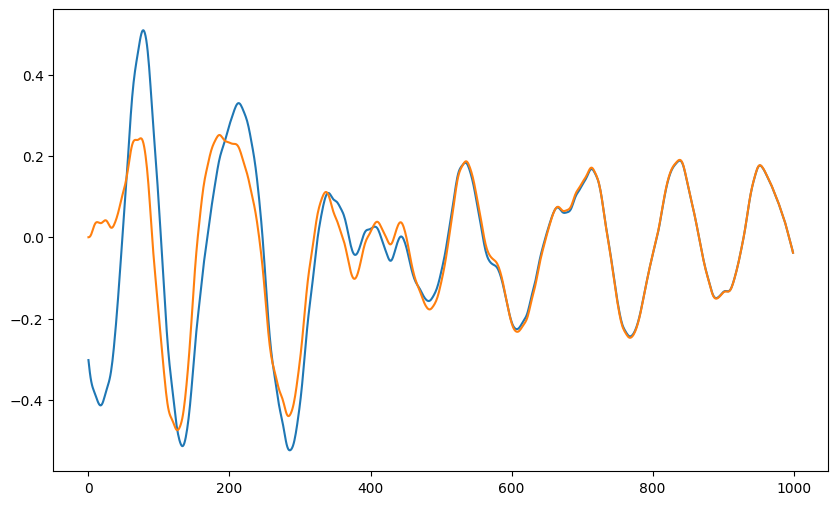

In [35]:
T = 1000

u_seq = make_u(rng, T, U_AMP_MAX)
_, y_hat_rand, _ = simulate(x0, u_seq)
x0_zero = np.zeros((2,))
_, y_hat_zero, _ = simulate(x0_zero, u_seq)
t = np.arange(T)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(t, y_hat_rand, label='rand')
ax.plot(t, y_hat_zero, label='zero')


1: traj_idx = 11, peak y = 0.784937, x0 = [-0.53798737  0.49851569], shape = (4001, 2)
2: traj_idx = 1, peak y = 0.732824, x0 = [0.00037874 0.32142885], shape = (4001, 2)
3: traj_idx = 42, peak y = 0.719524, x0 = [0.00666407 0.46851179], shape = (4001, 2)
4: traj_idx = 45, peak y = 0.712597, x0 = [0.56479686 0.39381761], shape = (4001, 2)
5: traj_idx = 29, peak y = 0.708842, x0 = [-0.15113621 -0.01002868], shape = (4001, 2)


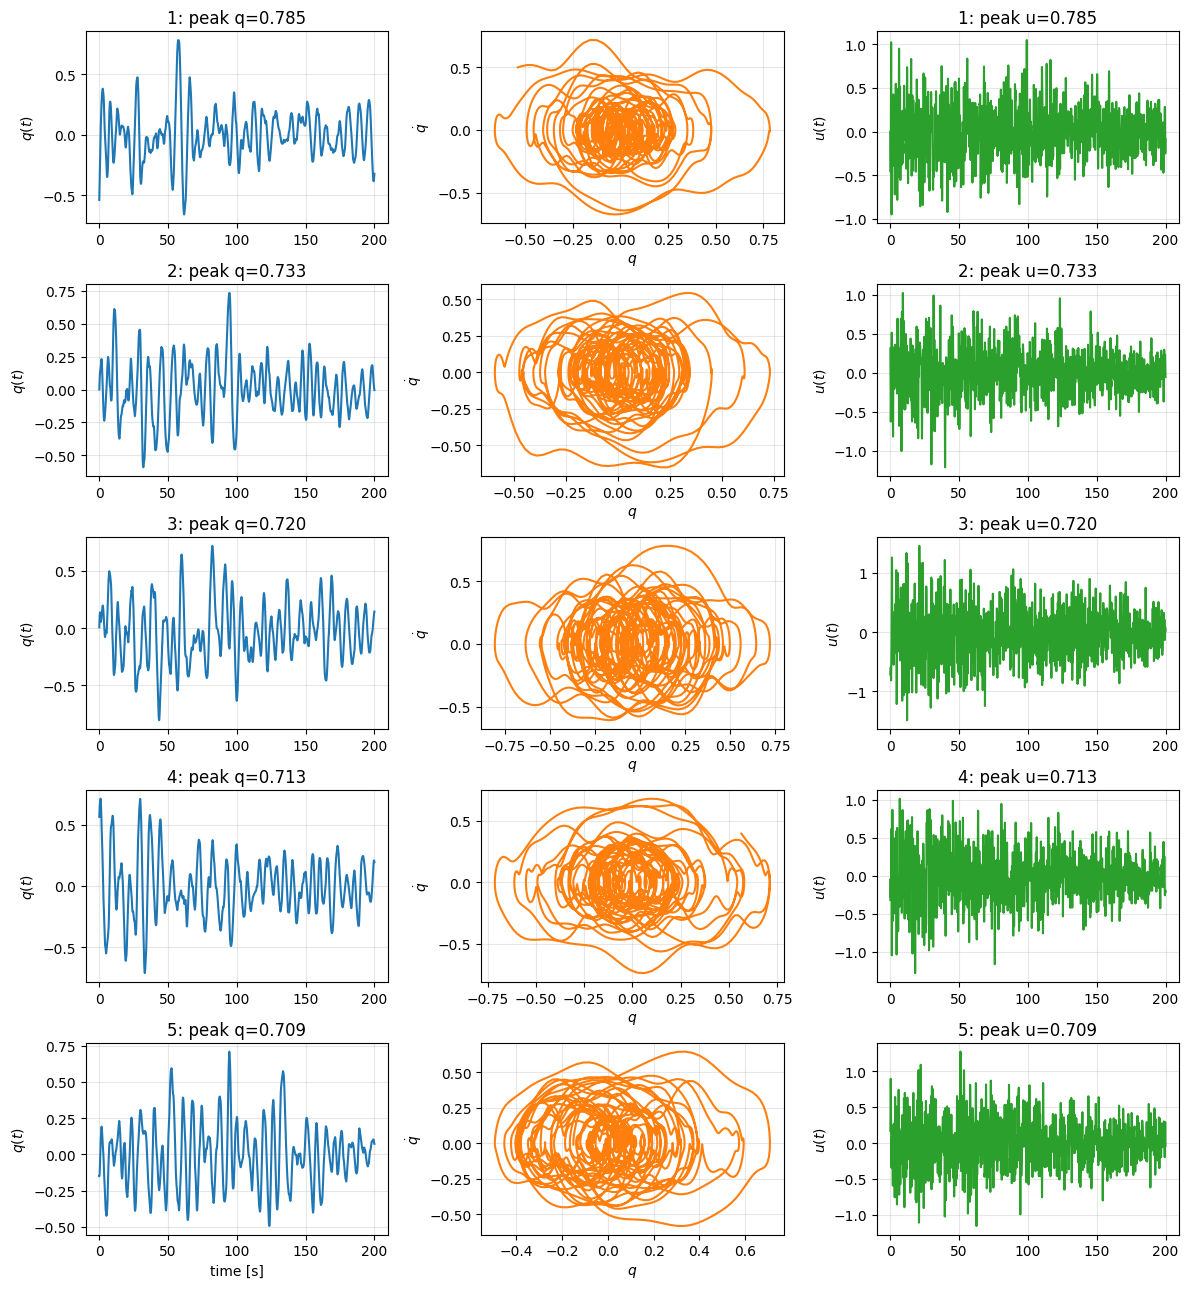

In [36]:
def top_k_trajectories_by_peak_y(trajs_list, k=5):
    scored = []
    for idx, traj in enumerate(trajs_list):
        y = traj["X"][:, 0]
        scored.append((np.max(y), idx, traj))
    scored.sort(key=lambda item: item[0], reverse=True)
    return scored[:k]

top5 = top_k_trajectories_by_peak_y(all_groups["rand_conv"], k=5)

fig, axes = plt.subplots(len(top5), 3, figsize=(12, 2.6 * len(top5)), squeeze=False)

for row, (peak_y, idx, traj) in enumerate(top5):
    X = traj["X"]
    u = traj["u"]
    t = np.arange(len(X)) * TS
    t2 = np.arange(len(u)) * TS

    print(f"{row+1}: traj_idx = {idx}, peak y = {peak_y:.6f}, x0 = {traj['x0']}, shape = {X.shape}")

    ax_y = axes[row, 0]
    ax_p = axes[row, 1]
    ax_u = axes[row, 2]
    ax_y.plot(t, X[:, 0], lw=1.5, color="C0")
    ax_y.set_ylabel(r"$q(t)$")
    ax_y.set_title(f"{row+1}: peak q={peak_y:.3f}")
    ax_y.grid(alpha=0.3)

    ax_p.plot(X[:, 0], X[:, 1], lw=1.5, color="C1")
    ax_p.set_xlabel(r"$q$")
    ax_p.set_ylabel(r"$\dot{q}$")
    ax_p.grid(alpha=0.3)

    ax_u.plot(t2, u, lw=1.5, color="C2")
    ax_u.set_ylabel(r"$u(t)$")
    ax_u.set_title(f"{row+1}: peak u={peak_y:.3f}")
    ax_u.grid(alpha=0.3)

axes[-1, 0].set_xlabel("time [s]")
plt.tight_layout()
plt.show()


In [37]:
# calculate the standard deviation of the inputs across all trajectories
all_u = []
for trajs in all_groups.values():
    for traj in trajs:
        all_u.append(traj['u'])
all_u = np.concatenate(all_u)
u_std = np.std(all_u)
print(f'Standard deviation of all inputs: {u_std:.6f}') 

# calculate the standard deviation of the outputs and states across all trajectories
all_q = []
all_dq = []
for trajs in all_groups.values():
    for traj in trajs:
        X = traj['X']
        all_q.append(X[:len(traj['u']), 0])   # q values corresponding to input length
        all_dq.append(X[:len(traj['u']), 1])  # dq values corresponding to input length
all_q = np.concatenate(all_q)
all_dq = np.concatenate(all_dq)
q_std = np.std(all_q)
dq_std = np.std(all_dq)
print(f'Standard deviation of all q values: {q_std:.6f}')
print(f'Standard deviation of all dq values: {dq_std:.6f}')

# sanity check
print(f' np.std(1/u_std * all_u): {np.std(1/u_std * all_u):.6f}')
print(f' np.std(1/q_std * all_q): {np.std(1/q_std * all_q):.6f}')
print(f' np.std(1/dq_std * all_dq): {np.std(1/dq_std * all_dq):.6f}')

Standard deviation of all inputs: 0.216683
Standard deviation of all q values: 0.154133
Standard deviation of all dq values: 0.141112
 np.std(1/u_std * all_u): 1.000000
 np.std(1/q_std * all_q): 1.000000
 np.std(1/dq_std * all_dq): 1.000000


In [38]:
# scale matrices for Lur'e model

S_x = np.diag([q_std, dq_std])
S_u = np.diag([u_std])
S_y = np.diag([q_std])

A = A_d2
B = B_d2
C = np.array([[1.0, 0.0]])
D = np.zeros((1, 1))
B2 = TS*np.vstack((
    np.zeros((1,nz)),
    W.reshape(1,-1) @ np.diag(d_thresh)
    ))
C2 = np.hstack((
    1/d_thresh.reshape(-1,1), np.zeros((nz, 1))
))
D12 = np.zeros((1, nz))
D21 = np.zeros((nz, 1))

# A_s = np.linalg.inv(S_x) @ A @ S_x
A_s = A
# B_s = np.linalg.inv(S_x) @ B @ S_u
B_s =  B @ S_u
# B2_s = np.linalg.inv(S_x) @ B2
B2_s = B2

C_s = np.linalg.inv(S_y) @ C
D_s = np.linalg.inv(S_y) @ D @ S_u
D12_s = np.linalg.inv(S_y) @ D12 

# C_s =  C
# D_s =  D @ S_u
# D12_s = D12 

C2_s = C2
D21_s = D21 @ S_u


# ── 7.6  Save Lur'e model parameters for use in duffing_analysis.ipynb ────────
lure_params_path = os.path.join('datasets', 'Duffing', 'lure_model_params_scaled.npz')
np.savez(lure_params_path,
         A=A_s, B=B_s, B2=B2_s, C=C_s, C2=C2_s,
         D=D_s, D12=D12_s, D21=D21_s,
         TS=TS, nz=nz, nx=A_s.shape[0], nu=B_s.shape[1], ny=C_s.shape[0])
print(f'Saved Lur\'e model parameters to {lure_params_path}')

Saved Lur'e model parameters to datasets/Duffing/lure_model_params_scaled.npz


In [39]:
model_scaled = LureModel(A_s, B_s, B2_s, C_s, C2_s, D_s, D12_s, D21_s)

std of u_s for rand_conv: 0.742474
std of y_s for rand_conv: 0.625741
std of y_hat_s for rand_conv: 0.680717


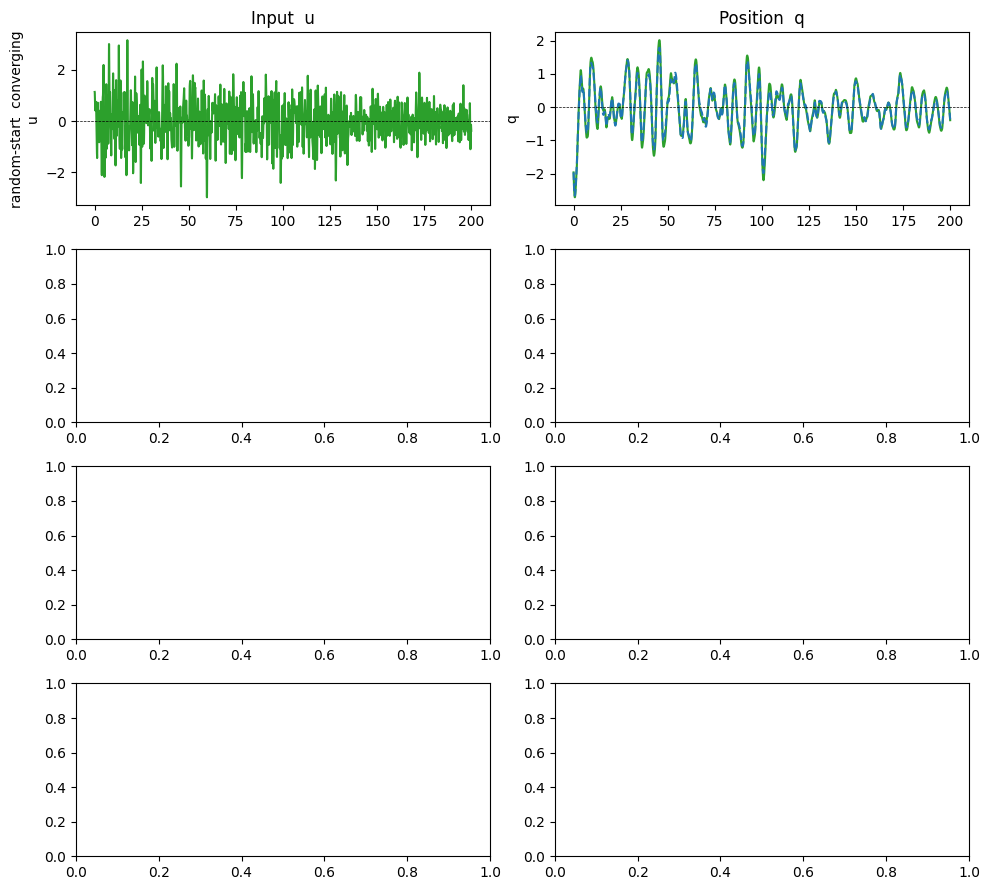

In [40]:
# plot scaled inputs and outputs for one trajectory from each group and compare it to the scaled lure system output


fig, axes = plt.subplots(4, 2, figsize=(10, 9))

# for row, gname in enumerate(['zero_conv', 'zero_div', 'rand_conv', 'rand_div']):
# for row, gname in enumerate(['zero_conv', 'zero_div']):
for row, gname in enumerate(['rand_conv']):
# for row, gname in enumerate(['zero_conv', 'rand_conv']):
    traj  = all_groups[gname][-1]     # first trajectory in each group
    
    x0 = traj['x0']
    # input
    u = np.array(traj['u'])

    N = len(u)
    t = np.arange(N) * TS

    u_s = u / S_u[0,0]  # scale by std of all inputs
    print(f'std of u_s for {gname}: {np.std(u_s):.6f}')
    
    X = traj['X']
    y_s = (X[:,0] / S_y[0,0])[:N]  # scale q by its std
    
    X_hat, y_hat_s, _ = model_scaled.simulate(x0, u_s)
    t2 = np.arange(len(y_hat_s)) * TS
    print(f'std of y_s for {gname}: {np.std(y_s):.6f}')
    print(f'std of y_hat_s for {gname}: {np.std(y_hat_s):.6f}')
    
    color = COLORS[gname]

    ax_u, ax_q = axes[row, 0], axes[row, 1]
    ax_u.plot(t, u_s, color=color)
    ax_u.axhline(0, color='k', lw=0.5, ls='--')
    ax_u.set_ylabel(f'{LABELS[gname]}\nu')

    ax_q.plot(t2, y_hat_s, color=color)
    ax_q.plot(t, y_s, ls='--')
    ax_q.axhline(0, color='k', lw=0.5, ls='--')
    ax_q.set_ylabel('q')

    if row == 3:
        ax_u.set_xlabel('time (s)')
        ax_q.set_xlabel('time (s)')

axes[0, 0].set_title('Input  u')
axes[0, 1].set_title('Position  q')
fig.tight_layout()
plt.show()
    



## 6  Export dataset as CSV files

All four groups (`zero_conv`, `zero_div`, `rand_conv`, `rand_div`) are
collected, shuffled, and split 60/10/30 into
`datasets/Duffing/{train,validation,test}/`.
Filenames preserve the original raw name (e.g. `rand_div_003.csv`) so
the case is always traceable.
The `datasets/Duffing/raw/` directory retains the full unmodified set.


In [41]:
import shutil, random

DUFFING_DIR = os.path.join('datasets', 'Duffing')

# collect all four groups
all_files = sorted(os.listdir(RAW_DIR))

rng_split = np.random.default_rng(42)
perm      = rng_split.permutation(len(all_files)).tolist()
shuffled  = [all_files[i] for i in perm]

N         = len(shuffled)
N_TRAIN   = round(N * 0.60)
N_VAL     = round(N * 0.10)
N_TEST    = N - N_TRAIN - N_VAL

split_files = {
    'train':      shuffled[:N_TRAIN],
    'validation': shuffled[N_TRAIN:N_TRAIN + N_VAL],
    'test':       shuffled[N_TRAIN + N_VAL:],
}

for split, files in split_files.items():
    split_dir = os.path.join(DUFFING_DIR, split)
    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)
    os.makedirs(split_dir)
    for fname in files:
        shutil.copy(os.path.join(RAW_DIR, fname),
                    os.path.join(split_dir, fname))

print(f'Total trajectories: {N}')
for split, files in split_files.items():
    print(f'  {split:12s}: {len(files)} files')
print()
# breakdown by kind within each split
for split, files in split_files.items():
    counts = {g: sum(1 for f in files if f.startswith(g))
              for g in ('zero_conv', 'zero_div', 'rand_conv', 'rand_div')}
    print(f'  {split:12s}: ' +
          '  '.join(f'{v} {k}' for k, v in counts.items()))


Total trajectories: 50
  train       : 30 files
  validation  : 5 files
  test        : 15 files

  train       : 0 zero_conv  0 zero_div  30 rand_conv  0 rand_div
  validation  : 0 zero_conv  0 zero_div  5 rand_conv  0 rand_div
  test        : 0 zero_conv  0 zero_div  15 rand_conv  0 rand_div


In [129]:
import pandas as pd
# load all csv training data from ./datasets/Duffing/train/ folder

dir = os.path.join('datasets', 'Duffing', 'train')
csv_files = [f for f in os.listdir(dir) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files in {dir}:')
u_names = ['u']
x_names = ['q', 'q_dot']
y_names = ['q']
# load x, y, u columns from each csv file using pandas

xs = []
ys = []
us = []
for f in csv_files:
    data = pd.read_csv(os.path.join(dir, f))
    x_data = data[x_names]
    y_data = data[y_names]
    u_data = data[u_names]
    xs.append(x_data)
    ys.append(y_data)
    us.append(u_data)

u_std = np.std(np.concatenate(us, axis=0))
X_std = np.std(np.concatenate(xs, axis=0), axis=0)
y_std = np.std(np.concatenate(ys, axis=0))

u_n = np.concatenate(us, axis=0) * 1/u_std
y_n = np.concatenate(ys, axis=0) * 1/y_std

print(f'Loaded data from {len(csv_files)} CSV files. Each file has {xs[0].shape[0]} samples.')

print(f'u_std: {u_std:.5f}, X_std: {X_std}, y_std: {y_std:.5f}')
print(f'u_n_std: {np.std(u_n):.5f}, y_n_std: {np.std(y_n):.5f}')


Found 120 CSV files in datasets/Duffing/train:
Loaded data from 120 CSV files. Each file has 200 samples.
u_std: 0.13753, X_std: [0.23579222 0.20019123], y_std: 0.23579
u_n_std: 1.00000, y_n_std: 1.00000


In [20]:
# Split and visual-inspection logic moved to cell above (Section 6).


## 7  Lur'e model construction & verification

We construct a **Lur'e-type recurrent model** that exactly represents the Duffing oscillator dynamics.

### Model structure

The discrete-time Lur'e model has the form:
$$
x^{k+1} = A\,x^k + B\,u^k + B_2\,w^k, \qquad
z^k = C_2\,x^k, \qquad w^k = \varphi(z^k)
$$

where $\varphi(z) = \sum_{k=1}^K W_k\,\mathrm{dzn}(z/d_k, 1)$ approximates the cubic nonlinearity.

### Duffing decomposition

- **State**: $x = [q, \dot{q}]^\top$ (position, velocity)
- **Linear dynamics**: $A$, $B$ from ZOH-discretized linearization at equilibrium
- **Nonlinearity**: $z = q$ (position), $w \approx q^3$ (cubic spring force)
- **Feedback**: $B_2 = B$ (force enters same channel as external input $u$)

### Approximation quality

We fit $\varphi(z) \approx z^3$ using $K=10$ deadzone functions over $[-5, 5]$ via least squares.
This section verifies the Lur'e model accurately reproduces Duffing trajectories.

Deadzone-sum approximation of z^3:  K=20,  max|error| = 78.2719  on [-5, 5]
Lure CRNN vs. Duffing ODE over 500 steps:
  q:   MAE = 0.0749,  max|err| = 0.3293
  dq:  MAE = 0.0700,  max|err| = 0.2309


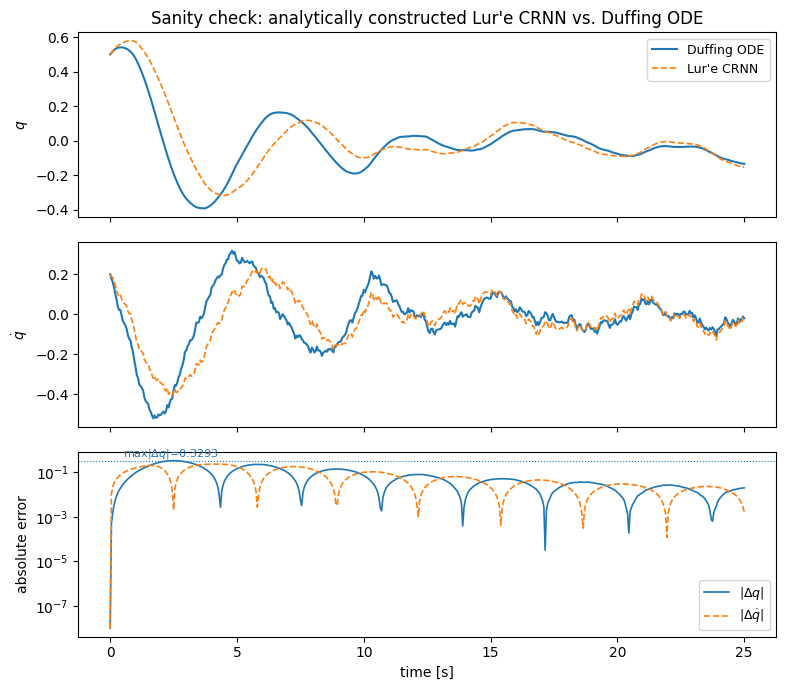

Saved: figs/duffing_lure_sanity.pdf


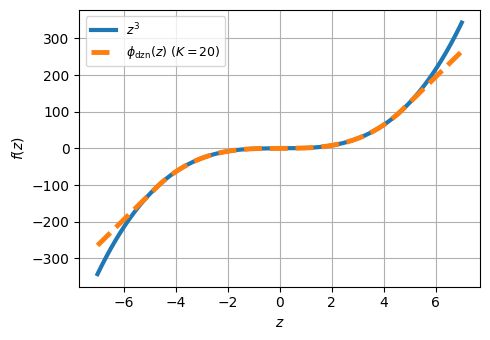

Saved: figs/duffing_dzn_approx.pdf


In [30]:
# ── Section 7: Lur'e CRNN sanity check ───────────────────────────────────

# ── 7.1  Approximate z^3 as a sum of deadzone functions ──────────────────
def dzn(z, d):
    """Scalar deadzone: max(|z| - d, 0) * sign(z)."""
    return np.maximum(np.abs(z) - d, 0.0) * np.sign(z)

K_DZN       = 20
DZN_RANGE   = 5     # fit on [-DZN_RANGE, DZN_RANGE]
d_thresh    = np.linspace(0.0, DZN_RANGE, K_DZN + 1)[1:]  # avoid d=0

z_fit  = np.linspace(-DZN_RANGE, DZN_RANGE, K_DZN)
Phi_fit = np.column_stack([d*dzn(z_fit/d, 1) for d in d_thresh])   # (600, K)
W, *_ = np.linalg.lstsq(Phi_fit, z_fit**3, rcond=None)

def phi_dzn(z):
    """Deadzone-sum approximation of z^3 (vectorised)."""
    z = np.asarray(z, dtype=float)
    return sum(W[k] * dzn(z, d_thresh[k]) for k in range(K_DZN))

z_test  = np.linspace(-(DZN_RANGE+2), (DZN_RANGE+2), 400)
approx_err = np.max(np.abs(phi_dzn(z_test) - z_test**3))
print(f'Deadzone-sum approximation of z^3:'
      f'  K={K_DZN},  max|error| = {approx_err:.4f}  on [-{DZN_RANGE}, {DZN_RANGE}]')


# ── 7.2  Construct Lur'e CRNN matrices from Duffing structure ────────────
# A, B from linearisation (already computed in Section 1b)
# B2 = B_d  (cubic spring enters same channel as u)
# C2 = [1, 0]  (z = x[0] = q)
A_lure  = A_d2                  # 2x2
B_lure  = B_d2[:, 0]            # 2,
B2_lure = B_d2[:, 0]            # 2,  same as B
C2_lure = np.array([1.0, 0.0]) # 1x2 -> scalar z = q

def lure_crnn_step(x, u):
    """One step of the analytically-constructed Lur'e CRNN."""
    z = C2_lure @ x             # scalar: z = q
    w = phi_dzn(z)              # nonlinear feedback
    return A_lure @ x + B_lure * u + B2_lure * w


# ── 7.3  Simulate and compare ────────────────────────────────────────────
rng_sc = np.random.default_rng(7)
T_sc   = 500
u_sc   = np.clip(rng_sc.normal(0.0, 0.3, T_sc), -0.5, 0.5)
x0_sc  = np.array([0.5, 0.2])
# x0_sc = np.array([-1.1,0.1])

X_gt_sc   = [x0_sc.copy()]
X_lure_sc = [x0_sc.copy()]
for k in range(T_sc):
    X_gt_sc.append(duffing_dt(X_gt_sc[-1], u=u_sc[k]))
    X_lure_sc.append(lure_crnn_step(X_lure_sc[-1], u_sc[k]))

X_gt_sc   = np.array(X_gt_sc)
X_lure_sc = np.array(X_lure_sc)
t_sc      = np.arange(T_sc + 1) * TS

mae_q  = np.mean(np.abs(X_gt_sc[:, 0] - X_lure_sc[:, 0]))
mae_dq = np.mean(np.abs(X_gt_sc[:, 1] - X_lure_sc[:, 1]))
max_q  = np.max(np.abs(X_gt_sc[:, 0] - X_lure_sc[:, 0]))
max_dq = np.max(np.abs(X_gt_sc[:, 1] - X_lure_sc[:, 1]))
print(f'Lure CRNN vs. Duffing ODE over {T_sc} steps:')
print(f'  q:   MAE = {mae_q:.4f},  max|err| = {max_q:.4f}')
print(f'  dq:  MAE = {mae_dq:.4f},  max|err| = {max_dq:.4f}')


# ── 7.4  Plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axes[0].plot(t_sc, X_gt_sc[:, 0],   'C0-',  lw=1.5, label='Duffing ODE')
axes[0].plot(t_sc, X_lure_sc[:, 0], 'C1--', lw=1.2, label="Lur'e CRNN")
axes[0].set_ylabel('$q$')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_title("Sanity check: analytically constructed Lur'e CRNN vs. Duffing ODE")

axes[1].plot(t_sc, X_gt_sc[:, 1],   'C0-',  lw=1.5)
axes[1].plot(t_sc, X_lure_sc[:, 1], 'C1--', lw=1.2)
axes[1].set_ylabel('$\\dot{q}$')

axes[2].semilogy(t_sc, np.abs(X_gt_sc[:, 0] - X_lure_sc[:, 0]) + 1e-8,
                 'C0-', lw=1.2, label='$|\\Delta q|$')
axes[2].semilogy(t_sc, np.abs(X_gt_sc[:, 1] - X_lure_sc[:, 1]) + 1e-8,
                 'C1--', lw=1.2, label='$|\\Delta\\dot{q}|$')
axes[2].set_ylabel('absolute error')
axes[2].set_xlabel('time [s]')
axes[2].legend(fontsize=9)
axes[2].axhline(max_q, color='C0', lw=0.8, ls=':')
axes[2].text(t_sc[-1]*0.02, max_q*1.5,
             f'max$|\\Delta q|$={max_q:.4f}', fontsize=8, color='C0')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'duffing_lure_sanity.pdf'), bbox_inches='tight')
plt.show()
print('Saved: figs/duffing_lure_sanity.pdf')


# ── 7.5  Dzn approximation quality plot ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 3.5))
ax2.plot(z_test, z_test**3,       'C0-',  lw=3.0, label='$z^3$')
ax2.plot(z_test, phi_dzn(z_test), 'C1--', lw=3.5,
         label=f'$\\phi_{{\\mathrm{{dzn}}}}(z)$ ($K={K_DZN}$)')
ax2.set_xlabel('$z$')
ax2.set_ylabel('$f(z)$')
# ax2.set_title('Deadzone-sum approximation of $z^3$')
ax2.legend(fontsize=9)
ax2.grid()
# ax2.text(0.02, 0.97,
#          f'max$|\\mathrm{{err}}| = {approx_err:.4f}$',
#          transform=ax2.transAxes, va='top', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'duffing_dzn_approx.pdf'), bbox_inches='tight')
plt.show()
print('Saved: figs/duffing_dzn_approx.pdf')


## Summary

Files written to `figs/`:
- `duffing_phase_portrait.pdf` + `.tex` — phase portrait with separatrix (PGFPlots for Beamer)
- `duffing_input_instability.pdf` — input-driven divergence example
- `duffing_discretization_comparison.pdf` — linear model comparison (Euler vs exact ZOH)
- `duffing_lure_sanity.pdf` — Lur'e CRNN vs. Duffing ODE trajectory comparison
- `duffing_dzn_approx.pdf` — deadzone-sum approximation of $z^3$

Files written to `datasets/Duffing/`:
- `lure_model_params.npz` — Lur'e model parameters (A, B, B2, C2, W, d_thresh) for analysis notebook
- `raw/zero_conv_NNN.csv` — converging trajectories from $x_0 = 0$
- `raw/zero_div_NNN.csv`  — diverging  trajectories from $x_0 = 0$
- `raw/rand_conv_NNN.csv` — converging trajectories from random $x_0$
- `raw/rand_div_NNN.csv`  — diverging  trajectories from random $x_0$
- `train/`, `validation/`, `test/` — 60/10/30 split of converging trajectories
